<a href="https://www.kaggle.com/code/lalit7881/ai-adoption-in-fortune-500-2020-25?scriptVersionId=309804727" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abidhussai512/ai-adoption-in-fortune-500-companies-20202025/ai-adoption-fortune500-synthetic-dataset-2020-2025.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abidhussai512/ai-adoption-in-fortune-500-companies-20202025/ai-adoption-fortune500-synthetic-dataset-2020-2025.csv")

In [3]:
df.head()

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score
0,2020,Amazon,E-commerce,USA,Real,Enterprise,4.535464e+11,Yes,Autonomous Driving,30.33,77
1,2021,Amazon,E-commerce,USA,Real,Enterprise,4.878035e+11,Yes,Generative AI,19.09,81
2,2022,Amazon,E-commerce,USA,Real,Enterprise,2.182500e+11,Yes,Supply Chain Optimization,34.99,79
3,2023,Amazon,E-commerce,USA,Real,Enterprise,4.114132e+11,Yes,Chatbots,23.96,72
4,2024,Amazon,E-commerce,USA,Real,Enterprise,3.191970e+11,No,NaN,0.00,27


In [4]:
df.tail()

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score
5995,2021,SyntheticCorp_0980,Telecom,Brazil,Synthetic,Enterprise,1.398673e+10,No,NaN,0.00,6
5996,2022,SyntheticCorp_0980,Finance,India,Synthetic,SME,2.847901e+07,Yes,Demand Forecasting,29.14,75
5997,2023,SyntheticCorp_0980,Technology,Canada,Synthetic,Enterprise,3.516618e+10,No,NaN,0.00,28
5998,2024,SyntheticCorp_0980,Logistics,UAE,Synthetic,Enterprise,2.835842e+10,Yes,Chatbots,38.37,41
5999,2025,SyntheticCorp_0980,Healthcare,Japan,Synthetic,SME,1.678214e+07,Yes,Predictive Maintenance,15.22,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               6000 non-null   int64  
 1   Company            6000 non-null   object 
 2   Industry           6000 non-null   object 
 3   Country            6000 non-null   object 
 4   Company_Type       6000 non-null   object 
 5   Employee_Size      6000 non-null   object 
 6   Revenue_USD        6000 non-null   float64
 7   Uses_AI            6000 non-null   object 
 8   Use_Case           4848 non-null   object 
 9   AI_ROI_Percent     6000 non-null   float64
 10  AI_Maturity_Score  6000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 515.8+ KB


In [6]:
df.describe()

,Year,Revenue_USD,AI_ROI_Percent,AI_Maturity_Score
count,6000.000000,6.000000e+03,6000.000000,6000.000000
mean,2022.500000,1.537110e+10,20.245257,54.491833
std,1.707967,4.400182e+10,12.657865,21.565809
min,2020.000000,1.010368e+06,0.000000,0.000000
25%,2021.000000,2.171382e+07,11.970000,43.000000
50%,2022.500000,4.255666e+07,21.480000,57.000000
75%,2024.000000,2.126462e+10,31.000000,71.000000
max,2025.000000,4.949976e+11,39.990000,100.000000


In [7]:
df.isnull().sum()

Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Case             1152
AI_ROI_Percent          0
AI_Maturity_Score       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Year                   int64
Company               object
Industry              object
Country               object
Company_Type          object
Employee_Size         object
Revenue_USD          float64
Uses_AI               object
Use_Case              object
AI_ROI_Percent       float64
AI_Maturity_Score      int64
dtype: object

In [10]:
df.shape

(6000, 11)

In [11]:
df.columns

Index(['Year', 'Company', 'Industry', 'Country', 'Company_Type',
       'Employee_Size', 'Revenue_USD', 'Uses_AI', 'Use_Case', 'AI_ROI_Percent',
       'AI_Maturity_Score'],
      dtype='object')

In [12]:
df.nunique()

Year                    6
Company              1000
Industry               12
Country                10
Company_Type            2
Employee_Size           2
Revenue_USD          6000
Uses_AI                 2
Use_Case               12
AI_ROI_Percent       2397
AI_Maturity_Score     101
dtype: int64

## EDA

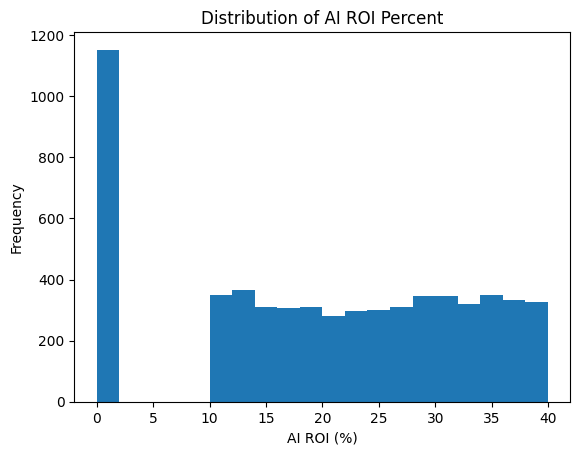

In [13]:
plt.figure()
plt.hist(df['AI_ROI_Percent'], bins=20)
plt.title("Distribution of AI ROI Percent")
plt.xlabel("AI ROI (%)")
plt.ylabel("Frequency")
plt.show()

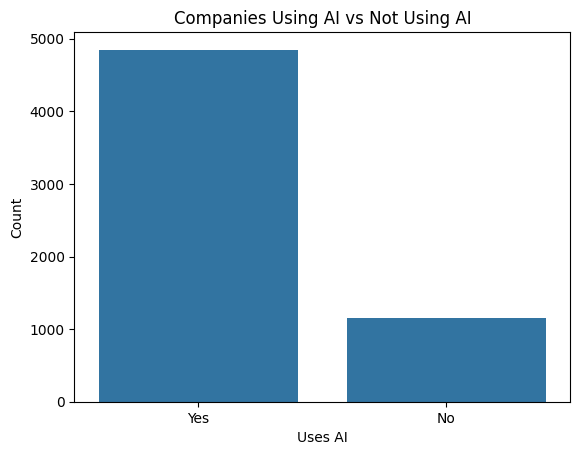

In [14]:
plt.figure()
sns.countplot(x='Uses_AI', data=df)
plt.title("Companies Using AI vs Not Using AI")
plt.xlabel("Uses AI")
plt.ylabel("Count")
plt.show()

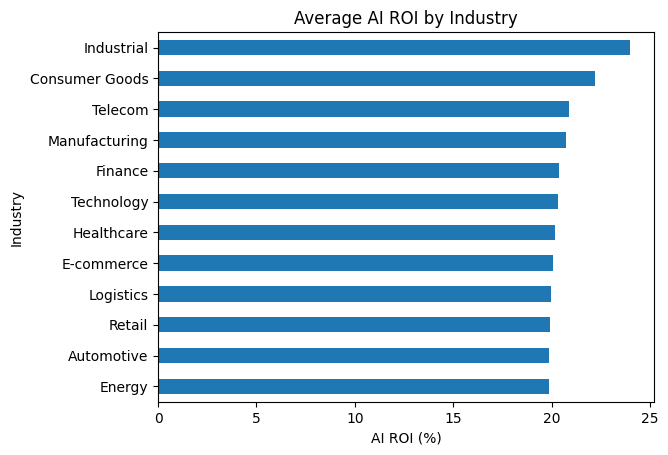

In [15]:
industry_roi = df.groupby('Industry')['AI_ROI_Percent'].mean().sort_values()

plt.figure()
industry_roi.plot(kind='barh')
plt.title("Average AI ROI by Industry")
plt.xlabel("AI ROI (%)")
plt.ylabel("Industry")
plt.show()

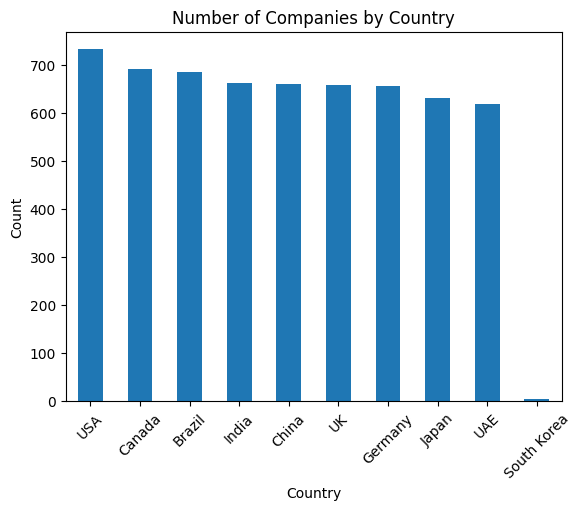

In [16]:
country_counts = df['Country'].value_counts()

plt.figure()
country_counts.plot(kind='bar')
plt.title("Number of Companies by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

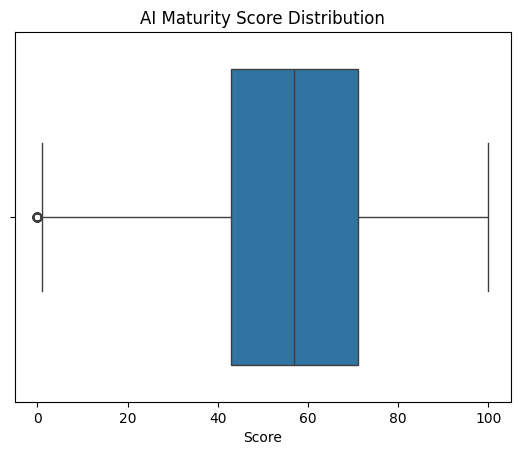

In [17]:
plt.figure()
sns.boxplot(x=df['AI_Maturity_Score'])
plt.title("AI Maturity Score Distribution")
plt.xlabel("Score")
plt.show()

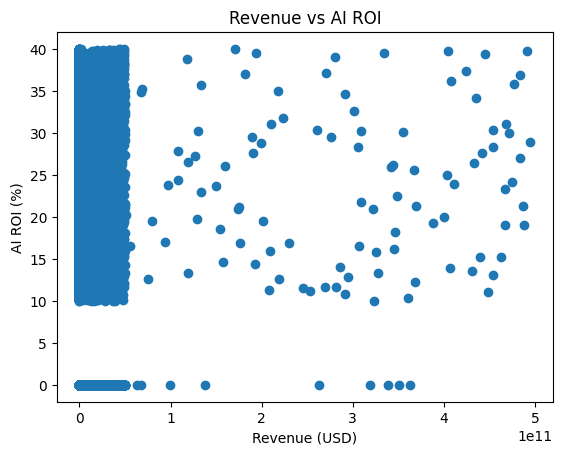

In [18]:
plt.figure()
plt.scatter(df['Revenue_USD'], df['AI_ROI_Percent'])
plt.title("Revenue vs AI ROI")
plt.xlabel("Revenue (USD)")
plt.ylabel("AI ROI (%)")
plt.show()

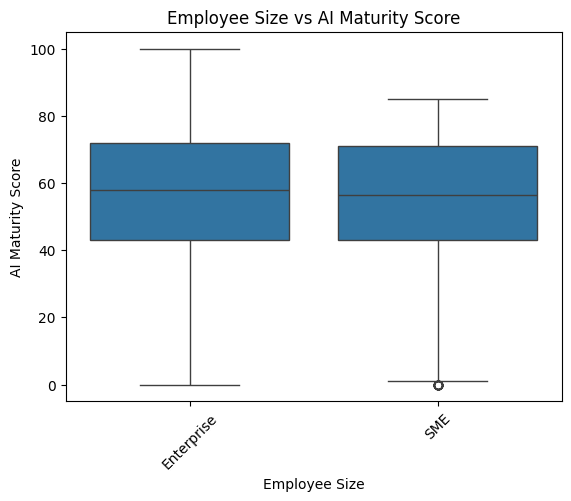

In [19]:
plt.figure()
sns.boxplot(x='Employee_Size', y='AI_Maturity_Score', data=df)
plt.title("Employee Size vs AI Maturity Score")
plt.xlabel("Employee Size")
plt.ylabel("AI Maturity Score")
plt.xticks(rotation=45)
plt.show()

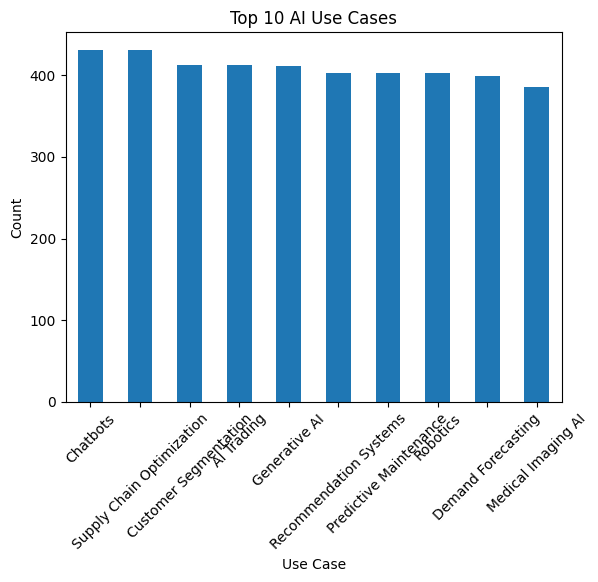

In [20]:
plt.figure()
df['Use_Case'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 AI Use Cases")
plt.xlabel("Use Case")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

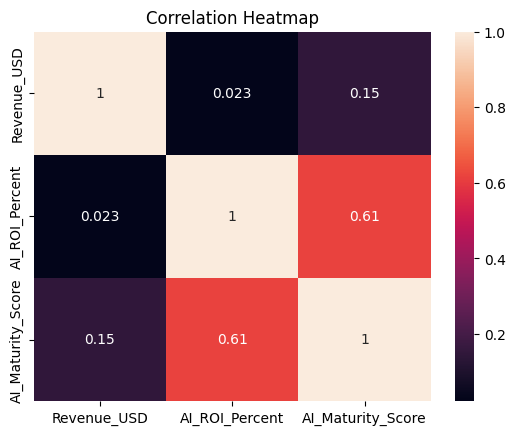

In [21]:
plt.figure()
corr = df[['Revenue_USD', 'AI_ROI_Percent', 'AI_Maturity_Score']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

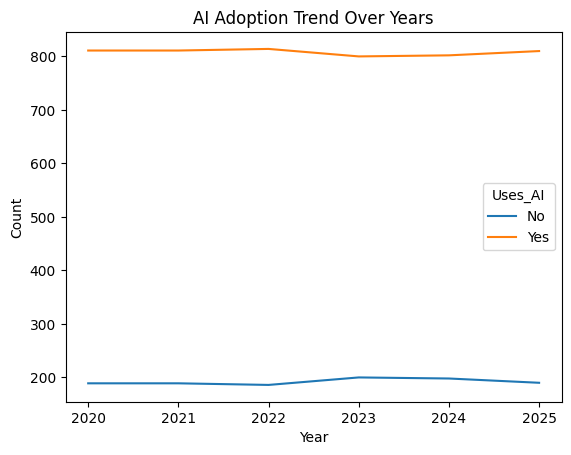

In [22]:
year_ai = df.groupby('Year')['Uses_AI'].value_counts().unstack()

year_ai.plot(kind='line')
plt.title("AI Adoption Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

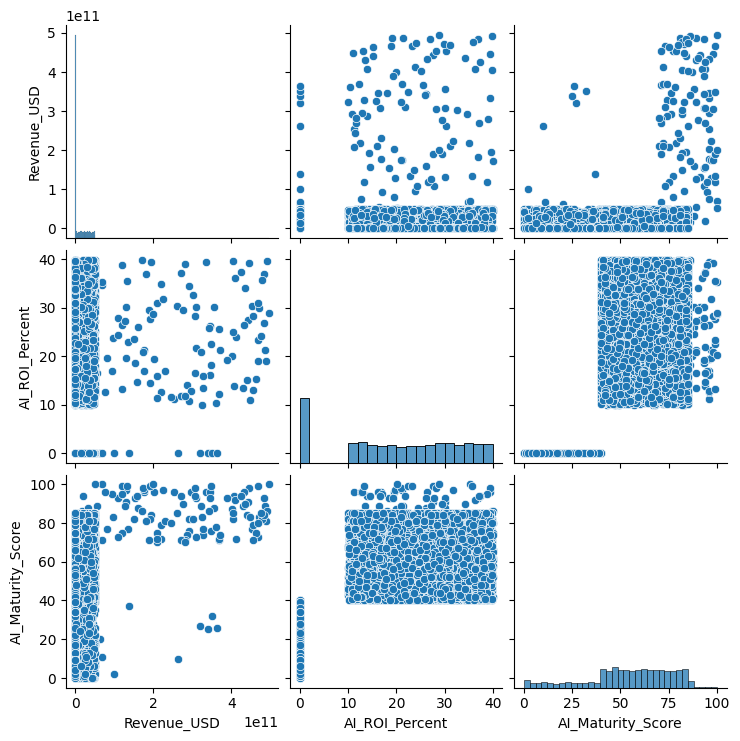

In [23]:
sns.pairplot(df[['Revenue_USD', 'AI_ROI_Percent', 'AI_Maturity_Score']])
plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [25]:
print(df.head())

   Year Company    Industry Country Company_Type Employee_Size   Revenue_USD  \
0  2020  Amazon  E-commerce     USA         Real    Enterprise  4.535464e+11   
1  2021  Amazon  E-commerce     USA         Real    Enterprise  4.878035e+11   
2  2022  Amazon  E-commerce     USA         Real    Enterprise  2.182500e+11   
3  2023  Amazon  E-commerce     USA         Real    Enterprise  4.114132e+11   
4  2024  Amazon  E-commerce     USA         Real    Enterprise  3.191970e+11   

  Uses_AI                   Use_Case  AI_ROI_Percent  AI_Maturity_Score  
0     Yes         Autonomous Driving           30.33                 77  
1     Yes              Generative AI           19.09                 81  
2     Yes  Supply Chain Optimization           34.99                 79  
3     Yes                   Chatbots           23.96                 72  
4      No                        NaN            0.00                 27  


In [26]:
target = 'Uses_AI'

In [27]:
X = df.drop(columns=[target])
y = df[target]

In [28]:
le_dict = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# Encode target separately
target_le = LabelEncoder()
y = target_le.fit_transform(y)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

results = {}


Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       230
           1       1.00      1.00      1.00       970

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       230
           1       1.00      1.00      1.00       970

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


SVM
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       230
           1       1.00      1.00      1.00       970

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00  

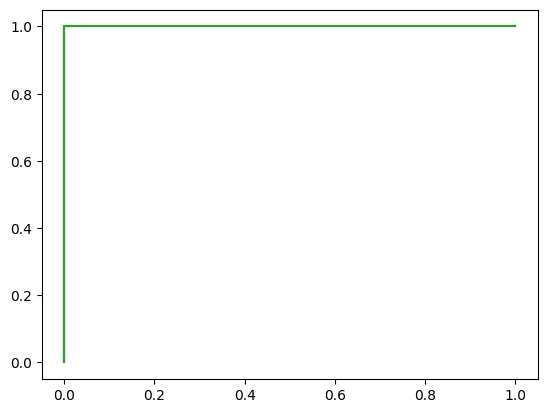

In [32]:
plt.figure()

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

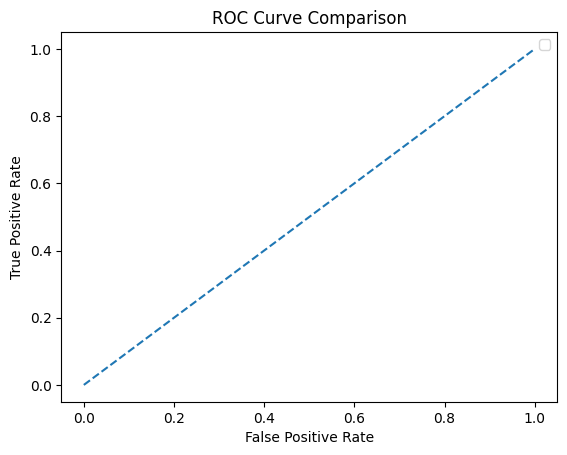

In [33]:
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [34]:
print("\nFinal Accuracy Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


Final Accuracy Comparison:
Logistic Regression: 1.0000
Random Forest: 1.0000
SVM: 1.0000


## Thank you...pls upvote!!!!!!